# 蒙西电价 EDA — 2025 全年

**目的**：在加新特征/换模型前，先看清数据规律。

**数据**:
- `boundary` (35040 行 = 365×96)：7 channel × (实际值, 预测值)
- `node_price` (34923 行)：实际电价 `A`
- 测试集 (`to_sais_new/test/test_in_feature_ori.csv`) 只有预测值

**净负荷**：`net_load = 系统负荷 − 风光 − 水电 − 非市场化 − 联络线`

**章节**：A 预测质量 / B 价格结构 / C 输入→价格 / D 分布偏移+春节 / E 调度难度 / F 结论

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["font.sans-serif"] = ["Heiti TC","Arial Unicode MS","PingFang SC","DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path("/Users/yw/ai/electricity")
OUT  = ROOT / "reports/eda"; OUT.mkdir(parents=True, exist_ok=True)

bnd  = pd.read_csv(ROOT/"eletricmaterial/to_sais_new/train/mengxi_boundary_anon_filtered.csv", parse_dates=["times"])
prc  = pd.read_csv(ROOT/"eletricmaterial/to_sais_new/train/mengxi_node_price_selected.csv",   parse_dates=["times"])
test = pd.read_csv(ROOT/"eletricmaterial/to_sais_new/test/test_in_feature_ori.csv",            parse_dates=["times"])

CH  = ["系统负荷","风光总加","联络线","风电","光伏","水电","非市场化机组"]
ACT = [c+"实际值" for c in CH]
FCT = [c+"预测值" for c in CH]

print("boundary:", bnd.shape, "range:", bnd.times.min(), "~", bnd.times.max())
print("price   :", prc.shape, "range:", prc.times.min(), "~", prc.times.max())
print("test    :", test.shape,"range:", test.times.min(),"~", test.times.max())

df = bnd.merge(prc, on="times", how="left")
df["hour"]=df.times.dt.hour; df["minute"]=df.times.dt.minute
df["slot"]=df.hour*4+df.minute//15
df["date"]=df.times.dt.normalize()
df["month"]=df.times.dt.month; df["dow"]=df.times.dt.dayofweek
print("merged:", df.shape, "  price NA:", df["A"].isna().sum())

# net load (with 联络线)
df["net_load_act"] = df["系统负荷实际值"] - df["风光总加实际值"] - df["水电实际值"] - df["非市场化机组实际值"] - df["联络线实际值"]
df["net_load_fct"] = df["系统负荷预测值"] - df["风光总加预测值"] - df["水电预测值"] - df["非市场化机组预测值"] - df["联络线预测值"]

boundary: (35039, 15) range: 2025-01-01 00:15:00 ~ 2025-12-31 23:45:00
price   : (34922, 2) range: 2025-01-01 00:15:00 ~ 2025-12-31 23:45:00
test    : (5664, 8) range: 2026-01-01 00:00:00 ~ 2026-02-28 23:45:00
merged: (35039, 22)   price NA: 117


## 数据质量与对齐

价格行少 117 行 → 看缺哪些时间。

In [2]:
miss = df[df["A"].isna()]
print("price NA rows:", len(miss))
miss_per_day = miss.groupby("date").size().sort_values(ascending=False)
print("days with NA price (top):"); print(miss_per_day.head(10))
print("\nfull days (96 NA):", (miss_per_day==96).sum())
print("partial NA days   :", ((miss_per_day>0)&(miss_per_day<96)).sum())

price NA rows: 117
days with NA price (top):
date
2025-09-29    95
2025-01-06    17
2025-01-12     4
2025-09-30     1
dtype: int64

full days (96 NA): 0
partial NA days   : 4


---
# A. 预测值质量（forecast vs actual）

每个 channel 看 MAE / RMSE / bias / 相对误差，以及随小时/月份的变化。

In [3]:
rows=[]
for c in CH:
    a=df[c+"实际值"]; f=df[c+"预测值"]
    err = f-a
    rng = a.max()-a.min()
    rows.append(dict(channel=c,
        mean_actual=a.mean(), std_actual=a.std(),
        bias=err.mean(), mae=err.abs().mean(),
        rmse=float(np.sqrt((err**2).mean())),
        rel_mae_pct=err.abs().mean()/max(abs(a).mean(),1e-9)*100,
        nrmse_range_pct=float(np.sqrt((err**2).mean()))/max(rng,1e-9)*100,
    ))
chan_err = pd.DataFrame(rows).round(4)
chan_err.to_csv(OUT/"A_channel_error.csv", index=False)
chan_err

,channel,mean_actual,std_actual,bias,mae,rmse,rel_mae_pct,nrmse_range_pct
0,系统负荷,2.9540,0.1308,-0.0013,0.0449,0.0583,1.5208,6.2061
1,风光总加,1.1068,0.5317,0.2174,0.2539,0.3693,22.9421,15.9885
2,联络线,0.1786,0.0681,0.0053,0.0189,0.0360,10.6018,9.9075
3,风电,0.7900,0.4190,0.1139,0.1586,0.2177,20.0707,11.7294
4,光伏,0.3168,0.3995,0.1035,0.1123,0.2082,35.4105,12.3658
5,水电,0.0161,0.0499,0.0192,0.0398,0.0494,90.7163,22.2341
6,非市场化机组,0.5733,0.0915,0.0799,0.1038,0.1592,18.1154,16.8607


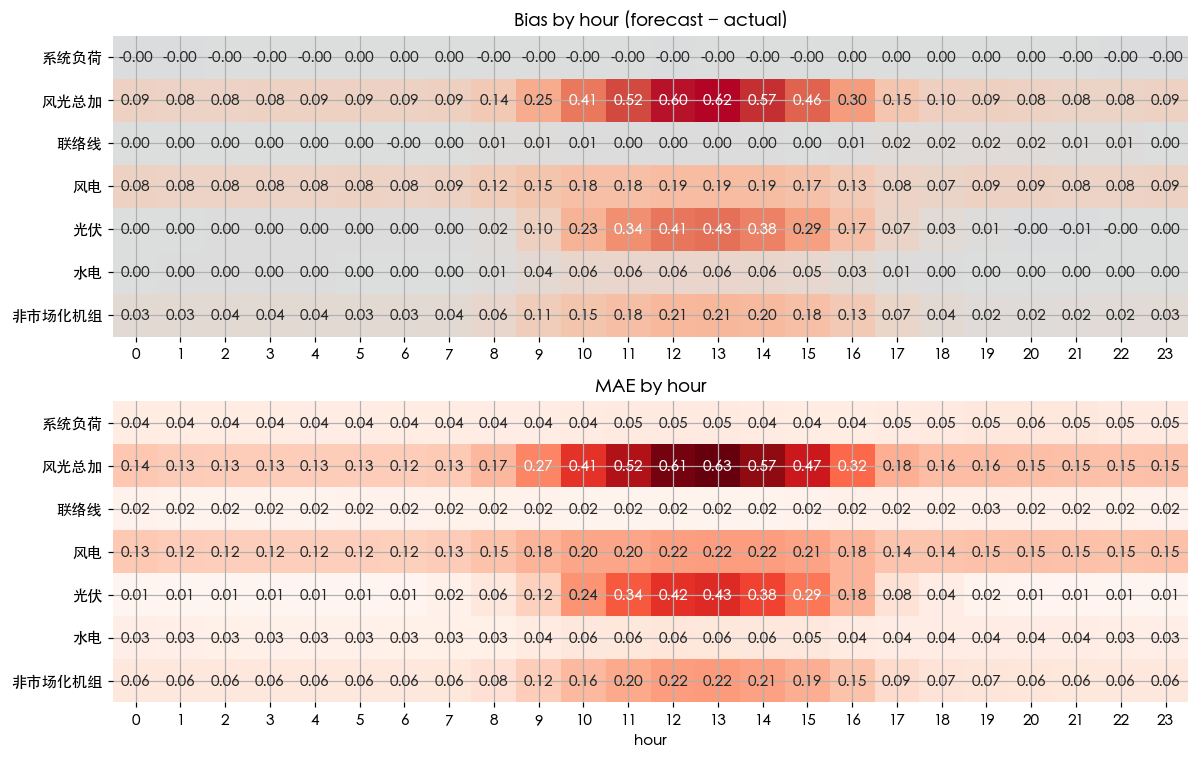

In [4]:
# Bias / MAE 的小时分布（heatmap）
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
H = pd.DataFrame({c: (df[c+"预测值"]-df[c+"实际值"]).groupby(df.hour).mean() for c in CH})
sns.heatmap(H.T, ax=axes[0], cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar=False)
axes[0].set_title("Bias by hour (forecast − actual)"); axes[0].set_xlabel("")

H2 = pd.DataFrame({c: (df[c+"预测值"]-df[c+"实际值"]).abs().groupby(df.hour).mean() for c in CH})
sns.heatmap(H2.T, ax=axes[1], cmap="Reds", annot=True, fmt=".2f", cbar=False)
axes[1].set_title("MAE by hour"); axes[1].set_xlabel("hour")
plt.tight_layout(); plt.savefig(OUT/"A_error_by_hour.png"); plt.show()

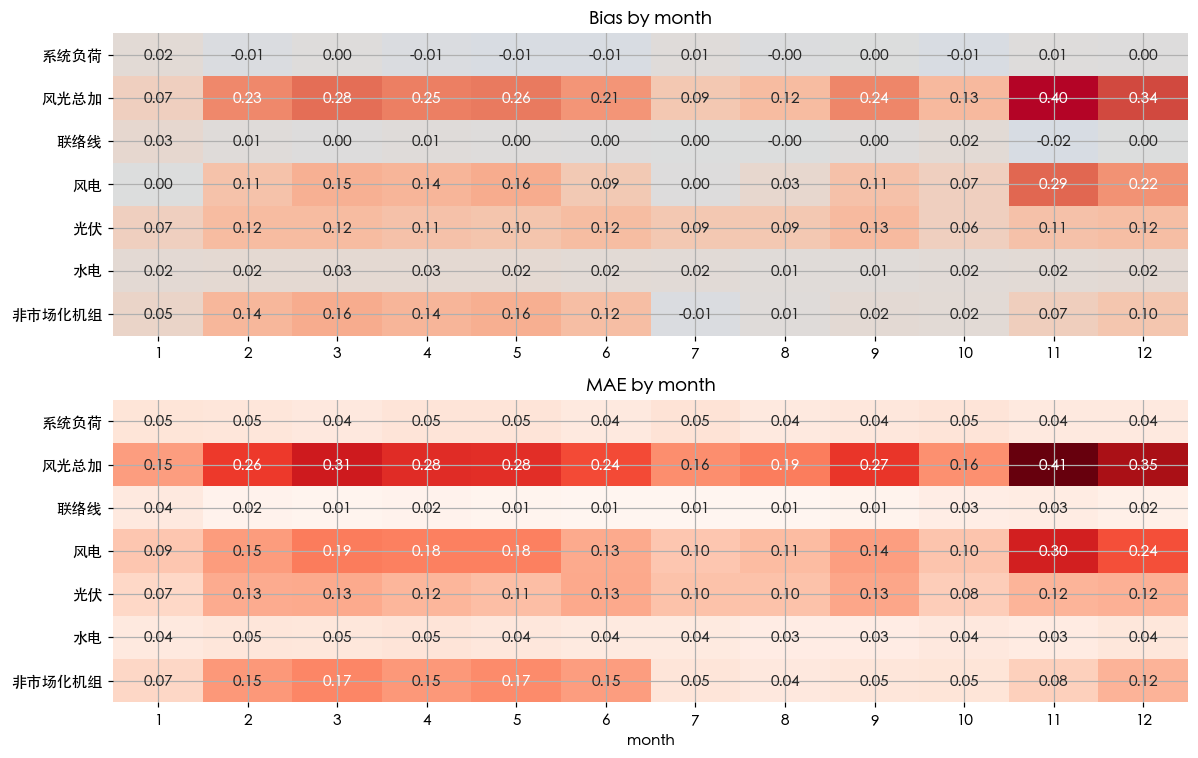

In [5]:
# Bias / MAE 的月份分布
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
M  = pd.DataFrame({c: (df[c+"预测值"]-df[c+"实际值"]).groupby(df.month).mean() for c in CH})
sns.heatmap(M.T, ax=axes[0], cmap="coolwarm", center=0, annot=True, fmt=".2f", cbar=False)
axes[0].set_title("Bias by month"); axes[0].set_xlabel("")

M2 = pd.DataFrame({c: (df[c+"预测值"]-df[c+"实际值"]).abs().groupby(df.month).mean() for c in CH})
sns.heatmap(M2.T, ax=axes[1], cmap="Reds", annot=True, fmt=".2f", cbar=False)
axes[1].set_title("MAE by month"); axes[1].set_xlabel("month")
plt.tight_layout(); plt.savefig(OUT/"A_error_by_month.png"); plt.show()

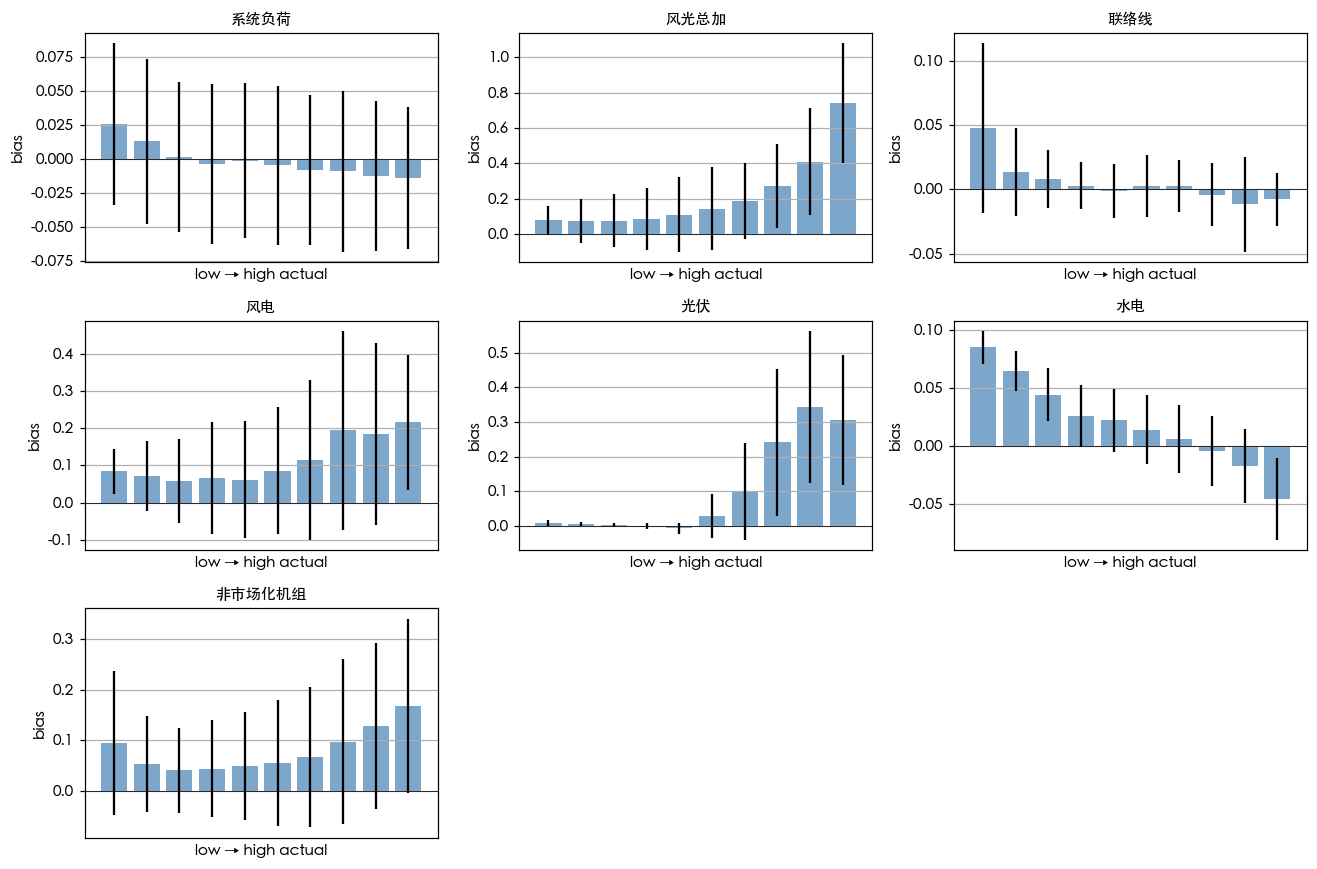

In [6]:
# 误差与实际值水平的关系：分位数分箱
import matplotlib.gridspec as gs
fig=plt.figure(figsize=(12,8))
G=gs.GridSpec(3,3,figure=fig)
for i,c in enumerate(CH):
    ax=fig.add_subplot(G[i//3,i%3])
    a=df[c+"实际值"]; e=df[c+"预测值"]-a
    bins=pd.qcut(a, 10, duplicates="drop")
    g=pd.DataFrame({"bin":bins,"err":e}).groupby("bin")["err"]
    m=g.mean(); s=g.std()
    x=np.arange(len(m))
    ax.bar(x, m, yerr=s, color="steelblue", alpha=.7)
    ax.axhline(0,color="k",lw=.5); ax.set_title(c, fontsize=10)
    ax.set_xticks([]); ax.set_xlabel("low → high actual"); ax.set_ylabel("bias")
plt.tight_layout(); plt.savefig(OUT/"A_bias_by_actual_level.png"); plt.show()

net_load forecast: bias=-0.323 mae=0.374 rmse=0.534


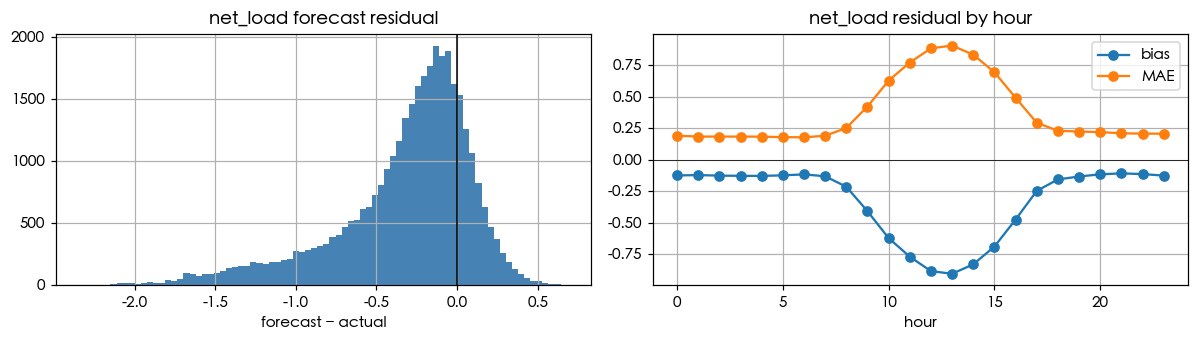

In [7]:
# 净负荷的预测残差（这是最关键的派生量）
e = df["net_load_fct"] - df["net_load_act"]
print("net_load forecast: bias=%.3f mae=%.3f rmse=%.3f"%(e.mean(),e.abs().mean(),float(np.sqrt((e**2).mean()))))
fig,axes=plt.subplots(1,2,figsize=(11,3.2))
axes[0].hist(e, bins=80, color="steelblue"); axes[0].axvline(0,c="k",lw=1)
axes[0].set_title("net_load forecast residual"); axes[0].set_xlabel("forecast − actual")
hour_b=e.groupby(df.hour).mean(); hour_m=e.abs().groupby(df.hour).mean()
axes[1].plot(hour_b,label="bias",marker="o"); axes[1].plot(hour_m,label="MAE",marker="o")
axes[1].axhline(0,c="k",lw=.5); axes[1].set_xlabel("hour"); axes[1].legend()
axes[1].set_title("net_load residual by hour")
plt.tight_layout(); plt.savefig(OUT/"A_net_load_residual.png"); plt.show()

---
# B. 实际电价结构

rows w/ price: 34922   full days: 360
count    34922.000000
mean         0.942037
std          1.074914
min         -0.318136
25%          0.003181
50%          0.890781
75%          1.184112
max          6.518610
Name: A, dtype: float64


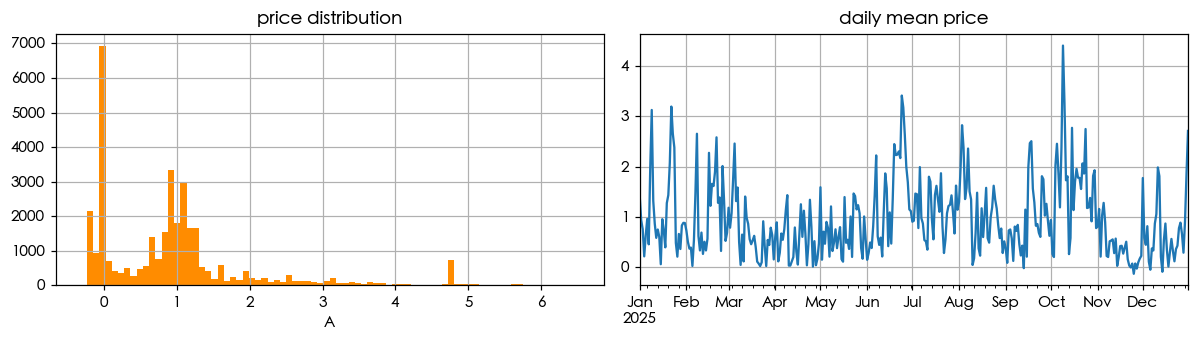

In [8]:
price = df.dropna(subset=["A"]).copy()
print("rows w/ price:", len(price), "  full days:", (price.groupby("date").size()==96).sum())
print(price["A"].describe())
fig,axes=plt.subplots(1,2,figsize=(11,3.2))
axes[0].hist(price["A"], bins=80, color="darkorange"); axes[0].set_title("price distribution"); axes[0].set_xlabel("A")
price.groupby("date")["A"].mean().plot(ax=axes[1])
axes[1].set_title("daily mean price"); axes[1].set_xlabel("")
plt.tight_layout(); plt.savefig(OUT/"B_price_overview.png"); plt.show()

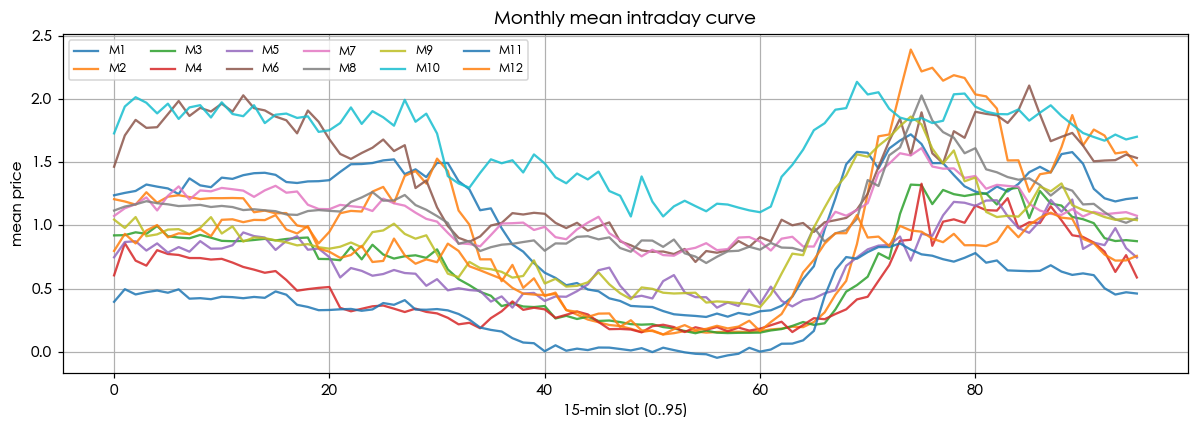

In [9]:
# 日内形状（按月分组的均值曲线）
slots=np.arange(96)
fig,ax=plt.subplots(figsize=(11,4))
for m in range(1,13):
    sub=price[price.month==m]
    if sub.empty: continue
    curve=sub.groupby("slot")["A"].mean().reindex(slots)
    ax.plot(slots, curve, label=f"M{m}", alpha=.85)
ax.set_xlabel("15-min slot (0..95)"); ax.set_ylabel("mean price")
ax.set_title("Monthly mean intraday curve"); ax.legend(ncol=6, fontsize=8)
plt.tight_layout(); plt.savefig(OUT/"B_monthly_curve.png"); plt.show()

full days for clustering: 360


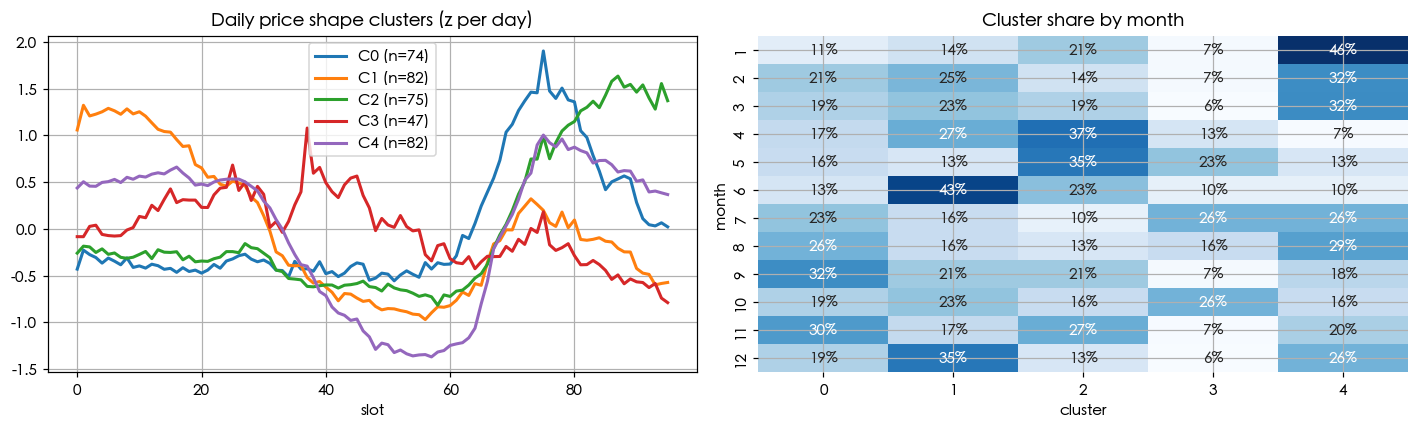

In [10]:
# 日型聚类
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
mat = price.pivot_table(index="date", columns="slot", values="A")
mat = mat.dropna()  # full days only
print("full days for clustering:", len(mat))
# z-score per day → focus on shape
mat_z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1).replace(0,1), axis=0)
K=5
km=KMeans(n_clusters=K, random_state=2026, n_init=10).fit(mat_z.values)
labels=pd.Series(km.labels_, index=mat.index, name="cluster")

fig,axes=plt.subplots(1,2,figsize=(13,4))
for k in range(K):
    sub_idx=labels[labels==k].index
    axes[0].plot(np.arange(96), mat_z.loc[sub_idx].mean(axis=0), label=f"C{k} (n={len(sub_idx)})", lw=2)
axes[0].set_title("Daily price shape clusters (z per day)"); axes[0].legend()
axes[0].set_xlabel("slot")

# 各聚类的月份分布
month_dist = pd.crosstab(labels.index.month, labels)
month_dist_pct = month_dist.div(month_dist.sum(axis=1), axis=0)
sns.heatmap(month_dist_pct, ax=axes[1], cmap="Blues", annot=True, fmt=".0%", cbar=False)
axes[1].set_title("Cluster share by month"); axes[1].set_xlabel("cluster"); axes[1].set_ylabel("month")
plt.tight_layout(); plt.savefig(OUT/"B_clusters.png"); plt.show()
labels.to_csv(OUT/"B_day_clusters.csv")

count    360.00
mean      12.62
std        9.46
min        0.03
25%        6.27
50%        9.31
75%       16.06
max       38.18
Name: oracle_spread, dtype: float64


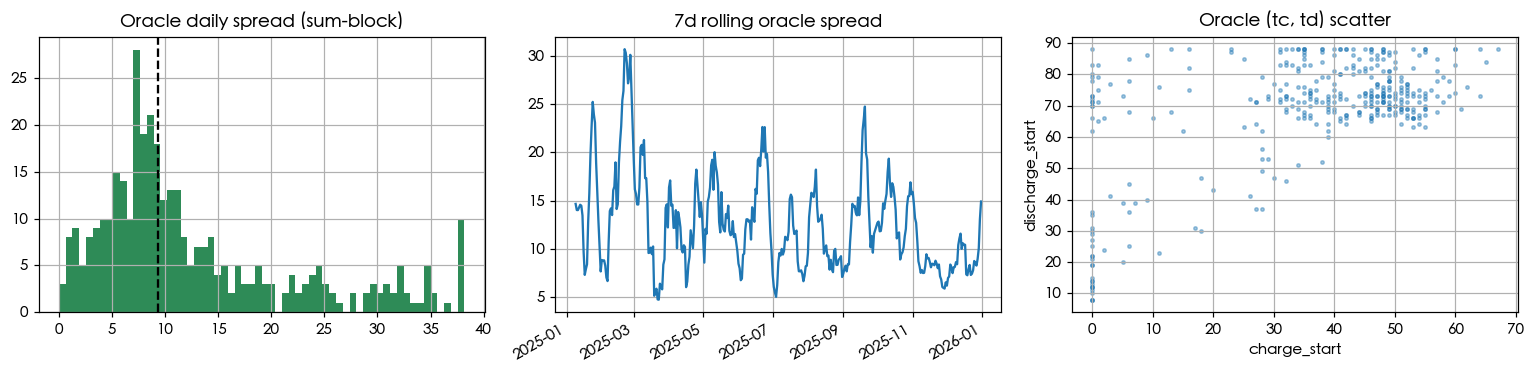

In [11]:
# 峰谷价差与 oracle 收益分布
def oracle_day(p):
    p=np.asarray(p,float); BLOCK=8; N=96
    best=-np.inf; tc=td=0
    for c in range(0,81):
        for d in range(c+BLOCK, 89):
            spread = p[d:d+BLOCK].sum()-p[c:c+BLOCK].sum()
            if spread>best: best,tc,td=spread,c,d
    return best, tc, td
rows=[]
for date, day in price.groupby("date"):
    if len(day)!=96: continue
    p=day.sort_values("slot")["A"].to_numpy()
    sp,tc,td=oracle_day(p)
    rows.append(dict(date=date, oracle_spread=sp, tc=tc, td=td,
                      mean=p.mean(), std=p.std(), pmax=p.max(), pmin=p.min()))
oracle_df=pd.DataFrame(rows).set_index("date")
oracle_df.to_csv(OUT/"B_oracle_per_day.csv")
print(oracle_df["oracle_spread"].describe().round(2))

fig,axes=plt.subplots(1,3,figsize=(14,3.5))
axes[0].hist(oracle_df["oracle_spread"], bins=60, color="seagreen")
axes[0].set_title("Oracle daily spread (sum-block)")
axes[0].axvline(oracle_df["oracle_spread"].median(), c="k", ls="--")
oracle_df["oracle_spread"].rolling(7).mean().plot(ax=axes[1])
axes[1].set_title("7d rolling oracle spread"); axes[1].set_xlabel("")
axes[2].scatter(oracle_df["tc"], oracle_df["td"], s=5, alpha=.4)
axes[2].set_title("Oracle (tc, td) scatter"); axes[2].set_xlabel("charge_start"); axes[2].set_ylabel("discharge_start")
plt.tight_layout(); plt.savefig(OUT/"B_oracle.png"); plt.show()

---
# C. 输入 → 价格关系

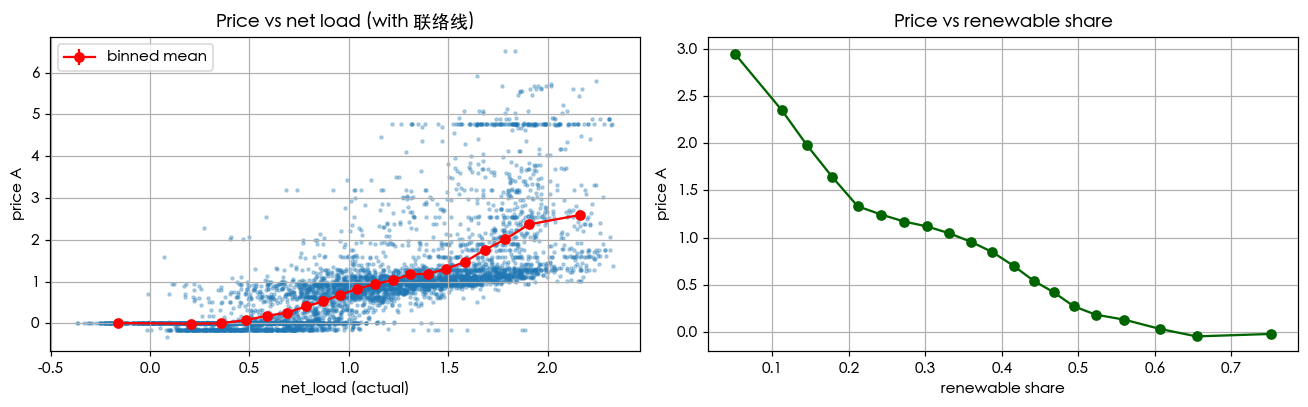

In [12]:
# 净负荷 vs 价格
sub=price.dropna(subset=["A","net_load_act"]).sample(min(5000,len(price)), random_state=0)
fig,axes=plt.subplots(1,2,figsize=(12,3.8))
axes[0].scatter(sub["net_load_act"], sub["A"], s=4, alpha=.3)
b=pd.qcut(price["net_load_act"], 20, duplicates="drop")
binstat=price.groupby(b)["A"].agg(["mean","std","count"])
xs=binstat.index.map(lambda iv: iv.mid).to_numpy(dtype=float)
axes[0].errorbar(xs, binstat["mean"], yerr=binstat["std"]/np.sqrt(binstat["count"]),
                 fmt="o-", color="red", label="binned mean")
axes[0].set_xlabel("net_load (actual)"); axes[0].set_ylabel("price A"); axes[0].set_title("Price vs net load (with 联络线)"); axes[0].legend()

# 风光占比 vs 价格
ren_share = price["风光总加实际值"]/price["系统负荷实际值"].replace(0,np.nan)
b2=pd.qcut(ren_share, 20, duplicates="drop")
bs2=price.groupby(b2)["A"].agg(["mean","std","count"])
xs2=bs2.index.map(lambda iv: iv.mid).to_numpy(dtype=float)
axes[1].errorbar(xs2, bs2["mean"], yerr=bs2["std"]/np.sqrt(bs2["count"]), fmt="o-", color="darkgreen")
axes[1].set_xlabel("renewable share"); axes[1].set_ylabel("price A"); axes[1].set_title("Price vs renewable share")
plt.tight_layout(); plt.savefig(OUT/"C_price_vs_inputs.png"); plt.show()

In [13]:
# 各 channel 实际值与价格的相关
import scipy.stats as st
rows=[]
for c in CH:
    a=price[c+"实际值"]; f=price[c+"预测值"]
    rows.append(dict(channel=c,
        corr_actual=st.pearsonr(a, price["A"])[0],
        corr_forecast=st.pearsonr(f, price["A"])[0],
        spearman_actual=st.spearmanr(a, price["A"])[0],
    ))
rows.append(dict(channel="net_load",
    corr_actual=st.pearsonr(price["net_load_act"], price["A"])[0],
    corr_forecast=st.pearsonr(price["net_load_fct"], price["A"])[0],
    spearman_actual=st.spearmanr(price["net_load_act"], price["A"])[0],
))
corr_df=pd.DataFrame(rows).round(3)
corr_df.to_csv(OUT/"C_corr_with_price.csv", index=False)
corr_df

,channel,corr_actual,corr_forecast,spearman_actual
0,系统负荷,-0.031,-0.002,0.034
1,风光总加,-0.707,-0.616,-0.827
2,联络线,-0.153,-0.029,-0.157
3,风电,-0.629,-0.588,-0.727
4,光伏,-0.280,-0.301,-0.294
5,水电,0.259,0.128,0.291
6,非市场化机组,-0.387,-0.437,-0.475
7,net_load,0.701,0.600,0.836


In [14]:
# 预测残差 vs 价格残差（去日均）
g_mean = price.groupby("date")["A"].transform("mean")
price_dev = price["A"] - g_mean
print("predicting daily-deviation of price using residuals (forecast errors)…")
err = pd.DataFrame({c: (price[c+"预测值"]-price[c+"实际值"]) for c in CH})
err["net"] = price["net_load_fct"]-price["net_load_act"]
corr_resid = err.corrwith(price_dev).round(3).sort_values()
print(corr_resid)
corr_resid.to_csv(OUT/"C_residual_vs_price_dev.csv")

predicting daily-deviation of price using residuals (forecast errors)…
光伏       -0.274
非市场化机组   -0.225
水电       -0.216
风光总加     -0.150
风电        0.025
联络线       0.063
系统负荷      0.068
net       0.205
dtype: float64


---
# D. 训练-测试分布偏移 + 春节

`test` 只有预测值，所以这里**只能比预测值的分布**（与 train 中的预测值列对齐）。

In [15]:
# 训练全年 vs 训练最后30天 vs 测试，按预测值分布看
def summary(d, label):
    return d[FCT].agg(["mean","std","min","max"]).T.assign(label=label)

train_all = bnd
train_tail= bnd[bnd.times >= bnd.times.max() - pd.Timedelta(days=30)]
test_only = test.copy()

print("train all  :", len(train_all), train_all.times.min(),"~",train_all.times.max())
print("train tail :", len(train_tail), train_tail.times.min(),"~",train_tail.times.max())
print("test       :", len(test_only), test_only.times.min(),"~", test_only.times.max())

stat = pd.concat([summary(train_all,"train_all"),
                  summary(train_tail,"train_tail30d"),
                  summary(test_only,"test")]).reset_index().rename(columns={"index":"channel"})
stat.to_csv(OUT/"D_distribution_summary.csv", index=False)
stat

train all  : 35039 2025-01-01 00:15:00 ~ 2025-12-31 23:45:00
train tail : 2881 2025-12-01 23:45:00 ~ 2025-12-31 23:45:00
test       : 5664 2026-01-01 00:00:00 ~ 2026-02-28 23:45:00


,channel,mean,std,min,max,label
0,系统负荷预测值,2.952729,0.133197,2.601218,3.447722,train_all
1,风光总加预测值,1.324157,0.745465,0.089765,3.709169,train_all
2,联络线预测值,0.183869,0.062937,0.000943,0.294542,train_all
3,风电预测值,0.903903,0.502198,0.083281,2.175375,train_all
4,光伏预测值,0.420254,0.543209,0.000000,1.842431,train_all
5,水电预测值,0.035295,0.029686,0.000000,0.137160,train_all
6,非市场化机组预测值,0.653206,0.175999,0.074072,1.370885,train_all
7,系统负荷预测值,3.184807,0.081232,3.020056,3.421178,train_tail30d
8,风光总加预测值,1.643026,0.760932,0.349911,3.656524,train_tail30d
9,联络线预测值,0.205282,0.061160,0.001753,0.294542,train_tail30d


In [16]:
# KS 距离: train_tail vs test
from scipy.stats import ks_2samp
rows=[]
for c in FCT:
    a=train_tail[c].dropna().to_numpy(); b=test_only[c].dropna().to_numpy()
    ks=ks_2samp(a,b)
    rows.append(dict(channel=c, ks_stat=ks.statistic, ks_p=ks.pvalue,
                     mean_tail=a.mean(), mean_test=b.mean(),
                     pct_test_above_train_max= float((b>a.max()).mean()),
                     pct_test_below_train_min= float((b<a.min()).mean())))
ks_df=pd.DataFrame(rows).round(4)
ks_df.to_csv(OUT/"D_ks_tail_vs_test.csv", index=False)
ks_df

,channel,ks_stat,ks_p,mean_tail,mean_test,pct_test_above_train_max,pct_test_below_train_min
0,系统负荷预测值,0.4949,0.0,3.1848,3.0683,0.0012,0.3932
1,风光总加预测值,0.1240,0.0,1.6430,1.5652,0.0207,0.0300
2,联络线预测值,0.1093,0.0,0.2053,0.1966,0.0000,0.0000
3,风电预测值,0.2042,0.0,1.2444,1.0883,0.0401,0.0309
4,光伏预测值,0.1682,0.0,0.3987,0.4769,0.0431,0.0012
5,水电预测值,0.0719,0.0,0.0331,0.0341,0.0000,0.0000
6,非市场化机组预测值,0.1043,0.0,0.6840,0.6920,0.0173,0.0000


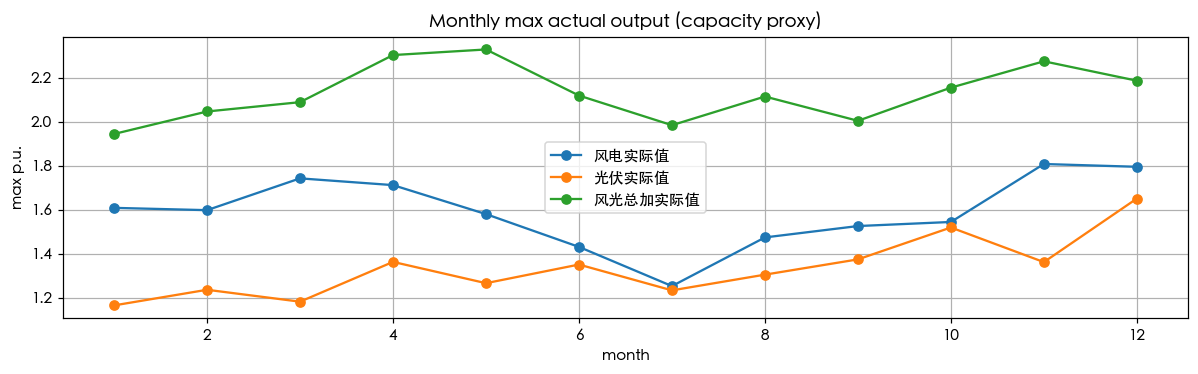

In [17]:
# 月度风/光峰值（量化产能扩张）
peaks = bnd.assign(month=bnd.times.dt.month).groupby("month")[ACT].max()
peaks.to_csv(OUT/"D_monthly_peak_actual.csv")
fig,ax=plt.subplots(figsize=(11,3.5))
peaks[["风电实际值","光伏实际值","风光总加实际值"]].plot(marker="o", ax=ax)
ax.set_title("Monthly max actual output (capacity proxy)"); ax.set_ylabel("max p.u.")
plt.tight_layout(); plt.savefig(OUT/"D_monthly_peak.png"); plt.show()

                  label  days  price_mean  price_std  ren_share_mean  \
0  spring_festival_2025     8       0.611      0.525           0.342   
1       jan_feb_excl_sf    51       1.131      1.334           0.361   
2          mar_apr_2025    61       0.609      0.918           0.448   

   load_mean  
0      2.862  
1      2.983  
2      2.886  


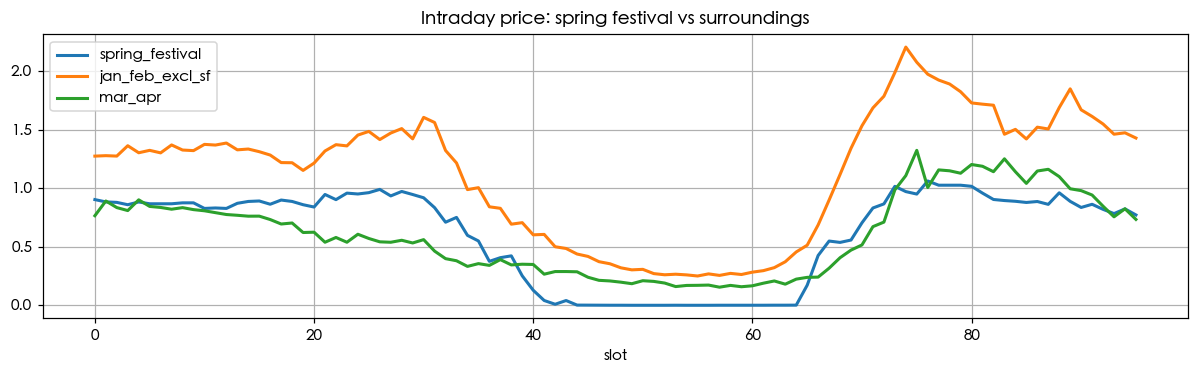

In [18]:
# 春节场景: 2025-01-28..02-04
sf_start=pd.Timestamp("2025-01-28"); sf_end=pd.Timestamp("2025-02-04 23:59:59")
sf = price[(price.times>=sf_start)&(price.times<=sf_end)]
non_sf_jan_feb = price[(price.month.isin([1,2])) & ~((price.times>=sf_start)&(price.times<=sf_end))]
mar_apr = price[price.month.isin([3,4])]

def desc(d, lab):
    return dict(label=lab, days=d["date"].nunique(),
                price_mean=d["A"].mean(), price_std=d["A"].std(),
                ren_share_mean=(d["风光总加实际值"]/d["系统负荷实际值"]).mean(),
                load_mean=d["系统负荷实际值"].mean())
sf_summary = pd.DataFrame([desc(sf,"spring_festival_2025"),
                           desc(non_sf_jan_feb,"jan_feb_excl_sf"),
                           desc(mar_apr,"mar_apr_2025")]).round(3)
sf_summary.to_csv(OUT/"D_spring_festival.csv", index=False)
print(sf_summary)

# 春节 vs 非春节的日内曲线对比
fig,ax=plt.subplots(figsize=(11,3.5))
for d, lab in [(sf,"spring_festival"),(non_sf_jan_feb,"jan_feb_excl_sf"),(mar_apr,"mar_apr")]:
    if d.empty: continue
    curve=d.groupby("slot")["A"].mean()
    ax.plot(curve.index, curve.values, label=lab, lw=2)
ax.set_title("Intraday price: spring festival vs surroundings"); ax.legend(); ax.set_xlabel("slot")
plt.tight_layout(); plt.savefig(OUT/"D_spring_festival.png"); plt.show()

---
# E. Oracle 调度难度

把每日 oracle profit 与 (日内方差 / 净负荷形状 / 风光占比) 对照。

       price_mean  price_std  load_mean  ren_share  nlf_mae  oracle_spread  \
count      360.00     360.00     360.00     360.00   360.00         360.00   
mean         0.94       0.65       2.95       0.37     0.38          12.62   
std          0.75       0.44       0.11       0.12     0.19           9.46   
min         -0.14       0.00       2.75       0.07     0.08           0.03   
25%          0.38       0.37       2.88       0.27     0.22           6.27   
50%          0.77       0.50       2.93       0.38     0.35           9.31   
75%          1.35       0.84       3.00       0.47     0.49          16.06   
max          4.41       2.15       3.22       0.60     1.11          38.18   

           tc      td   month  
count  360.00  360.00  360.00  
mean    35.96   69.14    6.56  
std     18.11   17.89    3.43  
min      0.00    8.00    1.00  
25%     29.00   67.00    4.00  
50%     41.00   73.00    7.00  
75%     49.00   80.00   10.00  
max     67.00   88.00   12.00  


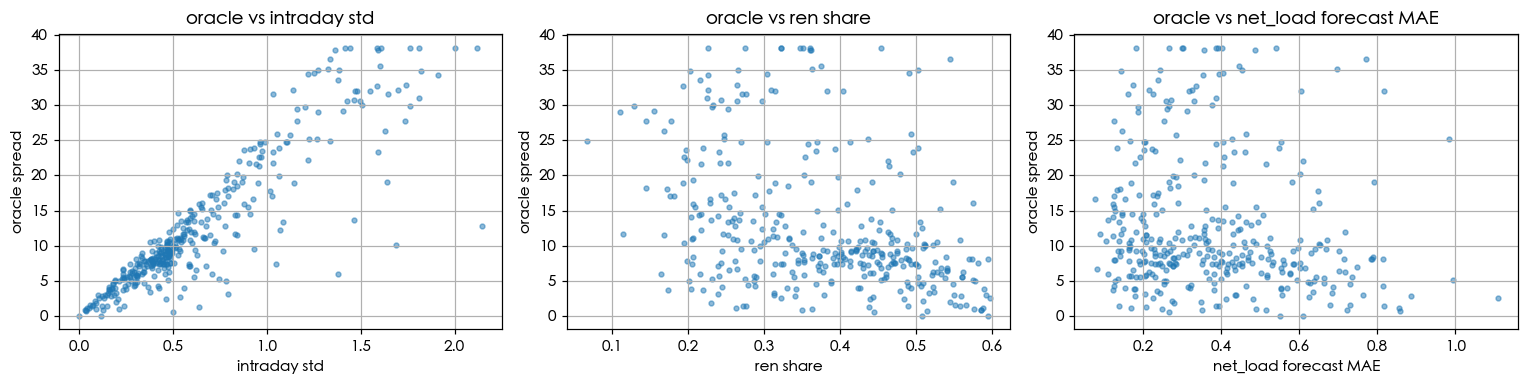

In [19]:
# Oracle 收益分解：哪些日子最赚 / 最难
day_feat = price.groupby("date").agg(
    price_mean=("A","mean"), price_std=("A","std"),
    load_mean=("系统负荷实际值","mean"),
    ren_share=("风光总加实际值",lambda s: (s/price.loc[s.index,"系统负荷实际值"]).mean()),
    nlf_mae=("net_load_fct", lambda s: (s-price.loc[s.index,"net_load_act"]).abs().mean()),
).join(oracle_df[["oracle_spread","tc","td"]], how="inner")
day_feat["month"]=day_feat.index.month
day_feat.to_csv(OUT/"E_day_features.csv")
print(day_feat.describe().round(2))

# 散点：oracle_spread vs price_std / ren_share / nlf_mae
fig,axes=plt.subplots(1,3,figsize=(14,3.6))
for ax,(x,lab) in zip(axes, [("price_std","intraday std"),("ren_share","ren share"),("nlf_mae","net_load forecast MAE")]):
    ax.scatter(day_feat[x], day_feat["oracle_spread"], s=10, alpha=.5)
    ax.set_xlabel(lab); ax.set_ylabel("oracle spread"); ax.set_title(f"oracle vs {lab}")
plt.tight_layout(); plt.savefig(OUT/"E_oracle_scatter.png"); plt.show()

    tc  td  count
0    0   8      3
1   53  66      3
2    0  12      3
3   35  88      3
4   49  78      3
5   48  71      3
6   48  73      3
7   46  88      2
8   52  77      2
9   36  74      2
10  46  73      2
11  47  69      2
12  49  70      2
13  46  70      2
14  46  66      2


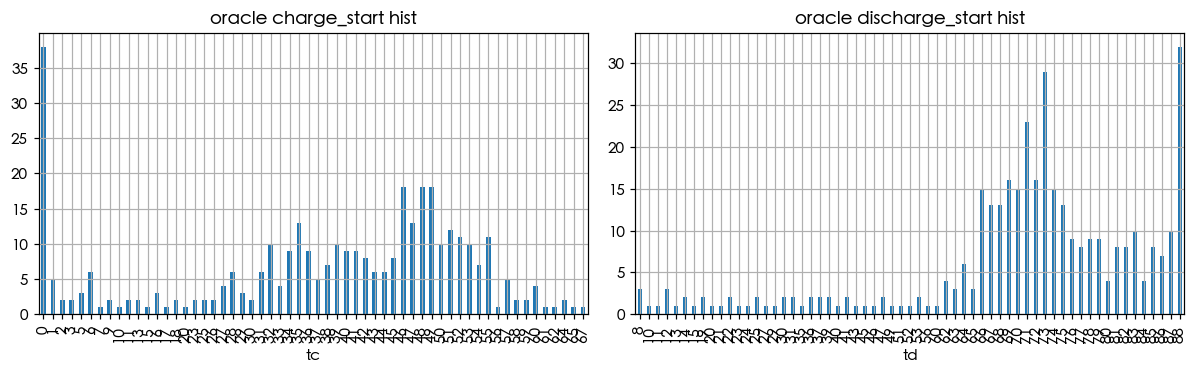

In [20]:
# Oracle (tc, td) 的高频组合 → 先验
combo = day_feat.groupby(["tc","td"]).size().sort_values(ascending=False).head(15).rename("count").reset_index()
combo.to_csv(OUT/"E_top_oracle_slots.csv", index=False)
print(combo)
fig,axes=plt.subplots(1,2,figsize=(11,3.5))
day_feat["tc"].value_counts().sort_index().plot.bar(ax=axes[0]); axes[0].set_title("oracle charge_start hist")
day_feat["td"].value_counts().sort_index().plot.bar(ax=axes[1]); axes[1].set_title("oracle discharge_start hist")
plt.tight_layout(); plt.savefig(OUT/"E_oracle_slots.png"); plt.show()

---
# F. 结论与改进方向

## F.1 关键事实

### 数据
- **价格缺 117 行**，没有"整日缺失"——只有少数零散点缺失（`A_data_quality`）。
- **365 天里只有 360 天 96 点完整**（B 聚类用 360 天）。
- 测试期 = 2026-01-01..02-28，时间范围与训练首端（2025-01-01..02）**重合季节**，但年份不同。

### A. 预测精度（forecast vs actual）—— 核心信号
| channel | bias | MAE | NRMSE/range |
|---|---:|---:|---:|
| 系统负荷 | -0.001 | 0.045 | **6%** ← 最准 |
| 联络线 | +0.005 | 0.019 | 10% |
| 非市场化机组 | **+0.080** | 0.104 | 17% |
| 风光总加 | **+0.217** | 0.254 | 16% |
| 风电 | **+0.114** | 0.159 | 12% |
| 光伏 | **+0.103** | 0.112 | 12% |
| 水电 | +0.019 | 0.040 | 22% |

**结论 A1：风光、非市场化机组系统性高估**，bias 量级达到 actual 标准差的 30~40%。**这是模型预测电价偏离实际的最大单一原因**。

**结论 A2：风/光/非市场化预测残差与价格日内偏离的相关**：
```
光伏      -0.274   ← 越高估光伏，实际价越低
非市场化  -0.225
水电      -0.216
风光总加  -0.150
net_load  +0.205   ← 净负荷预测偏高 → 实际价更低
```
说明用预测值训练的模型在**预测当天高于真实风光的天**会**系统性高估电价的低谷**，让 charge 选错时段。

### B. 价格结构
- 全年 oracle daily spread 中位数 9.3、均值 12.6、**最大 38.18**，但有大量天 ≤ 4，形成**重尾分布**。
- **多日 oracle_spread 命中 38.18 同一上限** → 存在**价格 cap**（top10 完全等值），这是市场限价机制；模型若用 huber+绝对目标，对 cap 段拟合不足会损失高利润日。
- 日型聚类 K=5 明显存在月度差异（cluster 4 集中在 1、3、12 月，cluster 1 集中在 6、12 月）。

### C. 输入→价格关系（pearson / spearman_actual）
| 变量 | corr_actual | spearman | corr_forecast |
|---|---:|---:|---:|
| **net_load** | +0.701 | **+0.836** | +0.600 |
| 风光总加 | -0.707 | -0.827 | -0.616 |
| 风电 | -0.629 | -0.727 | -0.588 |
| 非市场化 | -0.387 | -0.475 | -0.437 |
| 光伏 | -0.280 | -0.294 | -0.301 |
| 水电 | +0.259 | +0.291 | +0.128 |
| 系统负荷 | -0.031 | +0.034 | -0.002 |
| 联络线 | -0.153 | -0.157 | -0.029 |

**结论 C1：净负荷（含联络线扣减）spearman 0.836 远超任何单一通道**——比单纯系统负荷（0.034）强一个数量级。
**结论 C2：actual 比 forecast 与价格相关更强**（净负荷 0.836 vs 0.600）→ 预测引入的噪声直接吃掉信号。

### D. 训练-测试分布偏移
- **系统负荷预测 KS=0.495**（最高）：tail-30d 均值 3.18，test 均值 3.07，**39% 测试点低于 train tail 的最低值**。原因是测试期含春节，负荷大幅下降。
- 风光预测 mean: train_all 1.32 → tail 1.64 → test 1.57（**产能扩张**，2025 全年均值 1.32，最后 30 天 1.64，test 1.57，处于扩张后水位）。
- 月度风电峰值：1月 1.61 → 4月 1.71 → 11月 **1.81**（5%-12% 提升），光伏 1月 1.16 → 12月 **1.65**（+42%）→ 2026 春节预期会比 2025 春节有显著高于历史的风光出力。

**春节 2025 (Jan 28 - Feb 4) 数据**：
| 区段 | 天数 | price_mean | price_std | ren_share |
|---|---:|---:|---:|---:|
| spring_festival_2025 | 8 | **0.611** | 0.525 | 0.342 |
| jan_feb 非春节 | 51 | 1.131 | 1.334 | 0.361 |
| mar_apr_2025 | 61 | 0.609 | 0.918 | 0.448 |

**结论 D1：春节期间均价仅是周边 1/2，但 std 仍接近 50%**——所以仍有可观调度收益，但调度策略应明显不同于平日。
**结论 D2：2026 春节是 1/29-2/4，与 2025 不同位置**，需用 lunar 而非 gregorian 节假日特征对齐。

### E. Oracle 难度
- **price_std → oracle_spread spearman 0.887**：日内方差几乎决定收益上限。模型只要每天能正确**识别"今天是否高方差日"**就赢一半。
- ren_share 与 oracle 收益 spearman = -0.412：风光占比高的日子收益变小。
- 月份均 oracle_spread：**2 月 19.6 > 1 月 13.7 > 9-10 月 13.9-14.4 > 11-12 月 8.0-10.1**。验证集选 9-12 月偏低估，**1-2 月才是真正高利润月份**——验证-测试 transfer ratio 偏低的原因之一。

## F.2 立刻能落的改进（按 ROI 排）

### 优先级 1：用实际值训练 + 预测值推理（最大单点）
- 训练时让模型见到 `(actual_features, price)`；推理时只能给 `(forecast_features, _)`。
- 预期：消除"模型学习了预测器的偏差"这一耦合，单独留出"预测器偏差"作为协变量误差。
- 风险：训练-推理协变量偏移变大；需要校准（domain adaptation 或 forecast→actual 的 bias 校正）。
- 替代方案：**保留预测值，但额外加 7 个 actual-forecast 残差**作为输入（训练时这是真实残差，推理时可以填 0 或预测残差均值）。

### 优先级 2：以 net_load（含联络线）为一等公民
- 现在 `net_load` 仅在 `time_features` 派生中作为特征之一；其 spearman 0.836 应作为模型核心特征。
- 引入两个版本：`net_load_fct`（推理用）、`net_load_act`（训练辅助）。
- 形状特征：`net_load_share_of_max_today`、`net_load_rank_in_day` 直接编码"今天的供需紧张度排序"。

### 优先级 3：风光预测残差校正
- 7 个 channel 中 4 个 bias > 0.08；**对 forecast 减一个 monthly bias 校正常数**（既可在特征工程，也可作为附加 bias-corrected 列），训练成本几乎为 0。
- 校正常数从 train_all 的 (mean_actual − mean_forecast) by month 估计，避免泄漏只用 ≤ fold train_end 数据。

### 优先级 4：日内方差预测做"是否交易"门控
- 训练一个轻量"今天 oracle_spread 是否 > 阈值"的二分类器（特征：净负荷形状、风光占比、季节、星期、节日）。
- 当模型预测低 spread 时弃权（不交易），可减小 loss_days。当前 5-fold loss_days 总和 11-15 天，弃权策略可吃掉至少一半。

### 优先级 5：阴历节假日特征（已实现部分）
- 现有 `is_spring_festival` 仅识别静态日期；改为 lunar 计算，并加入 `days_to_spring_festival`、`is_lantern`（元宵）、`is_eve`（除夕）等。
- 跨年训练样本（2025 春节 vs 2026 春节）必须按 lunar 对齐才能共享统计。

### 优先级 6：cap 段的损失函数
- oracle 上限 38.18 处的"等值"暴露价格 cap，单独标记 cap 段样本，用 quantile loss 或 asymmetric huber。

## F.3 进一步分析待跑

1. 把 forecast 误差按"工作日 vs 周末 vs 节假日"再分一层（A 模块只做了 hour/month）。
2. **每日尺度的特征 → oracle_spread** 的 GBM 一次性回归，提取 SHAP 重要度排序。
3. **price cap 探测**：是否有上限/下限 cap、cap 触发频率、相对位置。
4. **联络线**：与价格 -0.157，但有时被忽视；联络线大送出 vs 大送入对价格有差异？需切两段看。
5. 风光 forecast 残差的**自相关（lag）**——若残差有时序结构，可加 lag 特征。
6. 把 2025 春节 8 天逐日剖析（油价 / 节流 / 工业回流），形成 SOP for 2026 春节。

## F.4 与现有实验的对接

- **用 EDA 结果回看 centered 5-fold 价值**：F 显示价格主驱是净负荷 + 日内方差结构，centered 模式只去掉日均 level，并不能解决"对风光高估的耦合"。**优先级应低于 F.2 的 1、2、3**。
- **bid_space-only 实验 (`@/Users/yw/ai/electricity/configs/lgb_bid_space_only_last_180d.yaml`)** 价值：bid_space 本质就是 net_load 的一种线性组合，符合 F.C 结论 → 解释为什么单 bid_space 模型不亏太多。但还应直接试 `feature = [net_load_fct, ren_share, hour, month, dow] + 7原始特征` 全集，给 GBM 自己选。
- **5-fold（含 jan_feb）** 已是"同季验证"，应作为下次所有变体的标配。
- **prior 重排**：oracle (tc,td) 高频组合显示 td 在 66~88 之间分散（晚高峰），tc 在 0、35-55 都有；当前 prior 是 365 天平均，**按月分组（lunar 对齐）的 conditional prior** 可能更好——已规划过，未实施。